In [3]:
import pandas as pd

In [4]:
#Exercice 1: top 5 et filtrage

voyageurs = pd.read_csv("../datasets/transilien_clean.csv")

# top 5 des gares les plus fréquentés
top5_gares = voyageurs.groupby('Nom Gare')['Somme de Montants'].sum().nlargest(5) 
print('Top 5 gares par fréquentation :') 
print(top5_gares,"\n") 


# Filtrer uniquement les jours ouvrables 
job = voyageurs[voyageurs['Type jour'] == 'JOB'] 
print('Shape jours ouvrables :', job.shape)

Top 5 gares par fréquentation :
Nom Gare
PARIS-GARE-DU-NORD     747021
PARIS-SAINT-LAZARE     310848
PARIS-GARE-DE-LYON     245713
SAINT-DENIS            159278
CHATELET-LES-HALLES    135361
Name: Somme de Montants, dtype: int64 

Shape jours ouvrables : (2502, 11)


## Exercice 3 — Top 5 et filtrage (Transilien)

**Ce que j'ai fait :**

Identifié les 5 gares les plus fréquentées avec nlargest()

et isolé les jours ouvrables avec un filtre sur la colonne Type jour.


**Pourquoi je l'ai fait :**

Sur un dataset de 7328 lignes couvrant des dizaines de gares,

nlargest() permet d'identifier immédiatement les gares qui

concentrent le trafic sans parcourir l'ensemble des résultats.

Le filtre JOB isole une population homogène avant toute

analyse comparative.


**Ce que ça m'a appris :**

Le trafic est très concentré : Paris-Gare-du-Nord domine

largement avec 747 021 voyageurs, soit plus du double de

Paris-Saint-Lazare (310 848). Les 5 premières gares sont

toutes parisiennes. Les jours ouvrables représentent 2502

lignes sur 7328 — environ un tiers du dataset, cohérent

avec le ratio 5 jours sur 7.

In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt 

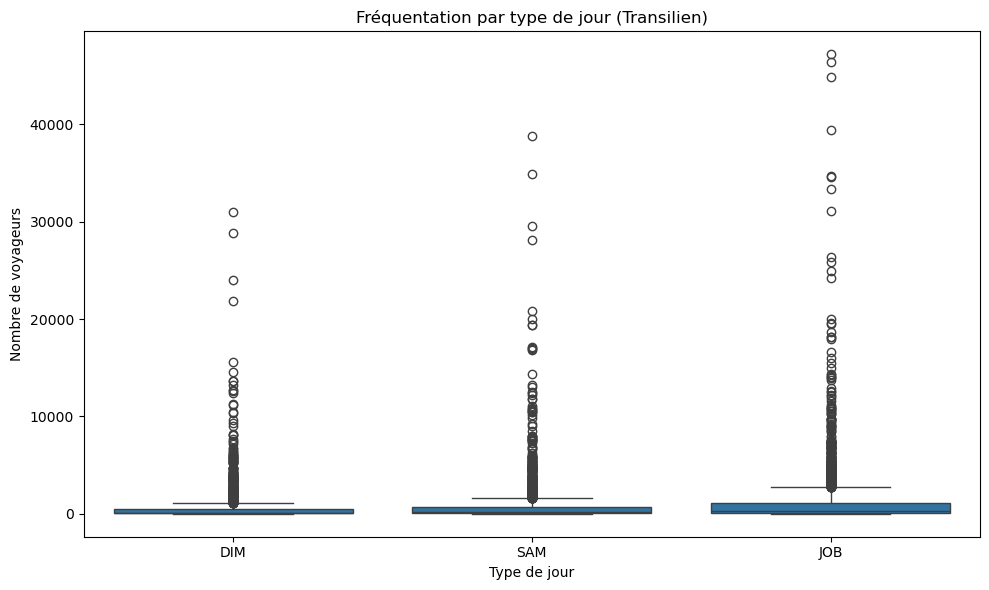

In [2]:
# exercice 5: visualisation statistiques avec seaborn
 
voyageurs = pd.read_csv('../datasets/transilien_clean.csv') 

# Boxplot : fréquentation par type de jour 
plt.figure(figsize=(10, 6)) 
sns.boxplot(data=voyageurs, x='Type jour', y='Somme de Montants') 
plt.title('Fréquentation par type de jour (Transilien)') 
plt.xlabel('Type de jour') 
plt.ylabel('Nombre de voyageurs') 
plt.tight_layout() 
plt.savefig('../visuals/frequentation_type_jour.png') 
plt.show() 

### Lecture — Fréquentation par type de jour (Transilien)


**Lecture d'un boxplot :**

- La boîte représente 50% des données (de Q1 à Q3)
- La ligne dans la boîte est la médiane
- Les points au-dessus sont les outliers — les valeurs extrêmes


Les trois boîtes (DIM, SAM, JOB) sont très plates et proches

de zéro — la médiane est faible pour les trois types de jours.
    
La majorité des tranches horaires enregistrent peu de voyageurs.

**Les outliers racontent une autre histoire :**
    
JOB : points jusqu'à 47 000 voyageurs — heures de pointe
      matin et soir très intenses en semaine

SAM : outliers jusqu'à 39 000 — des pics existent
      mais moins extrêmes qu'en semaine

DIM : boîte la plus plate, outliers jusqu'à 31 000
      — le jour le plus homogène et le moins chargé

**Constat :**

Quelques tranches d'heures de pointe concentrent

L'essentiel du trafic, encore plus marqué en semaine.

Ce résultat confirme visuellement le CV de 279% observé

avec describe() en semaine 1.